In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.head ()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

In [ ]:
df = df.dropna()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

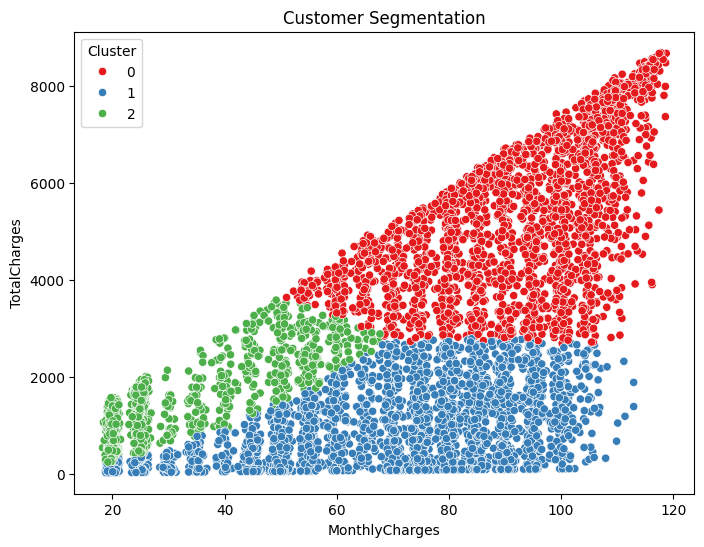

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['MonthlyCharges'],
    y=df['TotalCharges'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.show()

In [ ]:
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

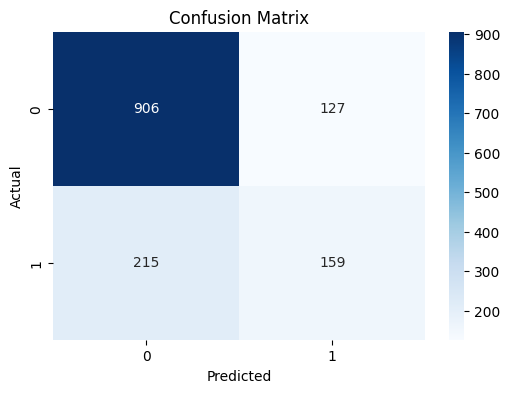

In [ ]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

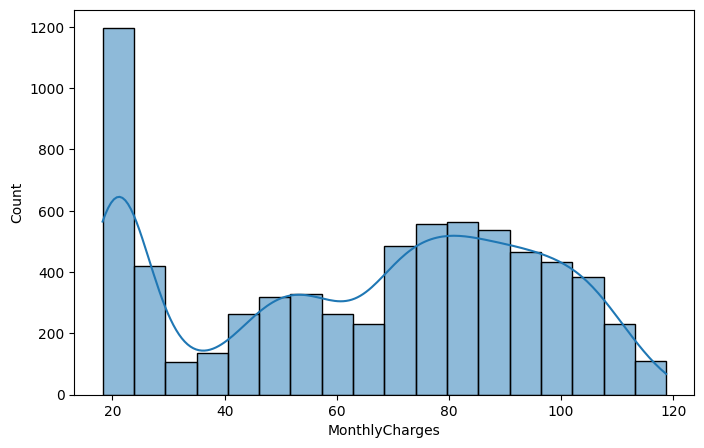

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    kde=True
)

plt.show()

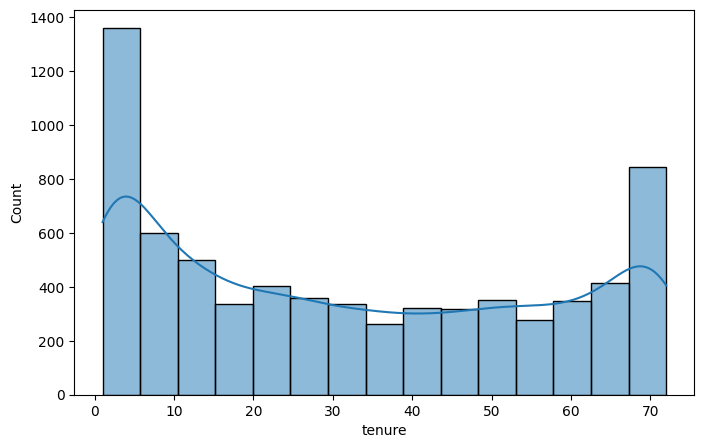

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    kde=True
)

plt.show()

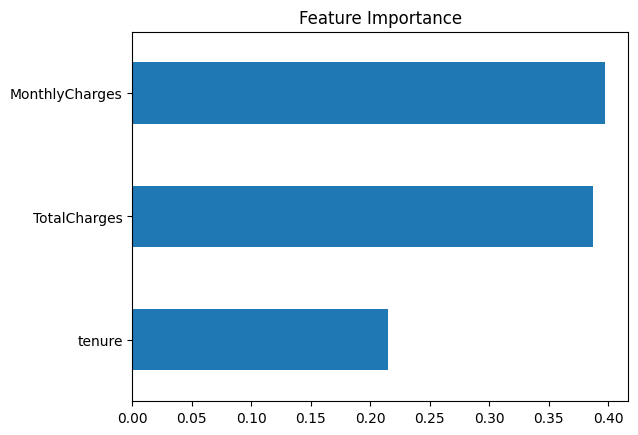

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle

st.set_page_config(page_title="Telecom Churn Prediction", layout="centered")

st.title("Telecom Customer Churn Prediction App")


model = pickle.load(open("model.pkl", "rb"))

gender = st.selectbox("Gender", ["Male", "Female"])
senior = st.selectbox("Senior Citizen", ["No", "Yes"])
partner = st.selectbox("Partner", ["No", "Yes"])
dependents = st.selectbox("Dependents", ["No", "Yes"])

tenure = st.number_input("Tenure (months)", 0, 100, 1)
monthly = st.number_input("Monthly Charges", 0.0, 200.0, 50.0)
total = st.number_input("Total Charges", 0.0, 10000.0, 100.0)

gender = 1 if gender == "Male" else 0
senior = 1 if senior == "Yes" else 0
partner = 1 if partner == "Yes" else 0
dependents = 1 if dependents == "Yes" else 0


if st.button("Predict"):

    input_data = np.array([[gender, senior, partner, dependents,
                            tenure, monthly, total]])

    prediction = model.predict(input_data)[0]

    if prediction == 1:
        st.error("Customer is likely to CHURN")
        st.write("This customer is at risk of leaving the company.")
        st.write("CHURN = YES → Customer will leave")
        st.write("CHURN = NO → Customer will stay")

    else:
        st.success("Customer is NOT likely to churn")
        st.write("This customer is likely to stay with the company.")
        st.write("CHURN = NO → Customer will stay")
        st.write("CHURN = YES → Customer will leave")

Writing app.py


In [ ]:
import numpy as np
import pickle

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})

features = ['gender','SeniorCitizen','Partner','Dependents',
            'tenure','MonthlyCharges','TotalCharges']

X = df[features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.7611940298507462


In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [ ]:
model = pickle.load(open("model.pkl", "rb"))

In [59]:
!streamlit run app.py &>/dev/null&

In [60]:
!pip install pyngrok

In [61]:
from pyngrok import ngrok

ngrok.set_auth_token("3FJR9eMGfcHACDViUmGxrEaMDOq_5ryHAcBnUkN67WT6p22e9")

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://composed-railing-grumbly.ngrok-free.dev" -> "http://localhost:8501"
